In [1]:
# Cell 1: Setup and Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE
from scipy import signal
import zipfile
import urllib.request
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")


2025-09-09 19:32:36.475238: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-09 19:32:36.475452: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-09 19:32:36.506572: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-09 19:32:37.385823: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

All libraries imported successfully!
TensorFlow version: 2.20.0


In [2]:
# Cell 2: Project Setup
BASE_PATH = "/home/stalin/Projects/Aval"
DATA_PATH = os.path.join(BASE_PATH, "data")
MODELS_PATH = os.path.join(BASE_PATH, "models")

# Create necessary directories
os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(os.path.join(DATA_PATH, "WISDM"), exist_ok=True)
os.makedirs(os.path.join(DATA_PATH, "UrbanSound8K"), exist_ok=True)
os.makedirs(os.path.join(DATA_PATH, "RAVDESS"), exist_ok=True)
os.makedirs(os.path.join(DATA_PATH, "CREMA-D"), exist_ok=True)
os.makedirs(os.path.join(DATA_PATH, "FER2013"), exist_ok=True)

print(f"Project structure created at: {BASE_PATH}")
print("Directory structure ready!")


Project structure created at: /home/stalin/Projects/Aval
Directory structure ready!


In [3]:
# Cell 3: Dataset Download Functions
def download_wisdm_dataset():
    """Download WISDM dataset"""
    url = "https://www.cis.fordham.edu/wisdm/includes/datasets/latest/WISDM_ar_latest.tar.gz"
    local_path = os.path.join(DATA_PATH, "WISDM", "WISDM_ar_latest.tar.gz")
    
    if not os.path.exists(local_path):
        print("Downloading WISDM dataset...")
        urllib.request.urlretrieve(url, local_path)
        
        # Extract the dataset
        import tarfile
        with tarfile.open(local_path, 'r:gz') as tar:
            tar.extractall(os.path.join(DATA_PATH, "WISDM"))
        print("WISDM dataset downloaded and extracted!")
    else:
        print("WISDM dataset already exists!")

def create_sample_datasets():
    """Create sample datasets for demonstration purposes"""
    # Create sample WISDM data
    wisdm_data = []
    activities = ['Walking', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Downstairs']
    
    for i in range(10000):
        user_id = np.random.randint(1, 36)
        activity = np.random.choice(activities)
        timestamp = i * 50  # 20Hz sampling
        acc_x = np.random.normal(0, 2)
        acc_y = np.random.normal(0, 2)
        acc_z = np.random.normal(9.8, 1)
        
        wisdm_data.append([user_id, activity, timestamp, acc_x, acc_y, acc_z])
    
    wisdm_df = pd.DataFrame(wisdm_data, columns=['user', 'activity', 'timestamp', 'x', 'y', 'z'])
    wisdm_df.to_csv(os.path.join(DATA_PATH, "WISDM", "WISDM_ar_v1.1_raw.txt"), index=False)
    
    print("Sample datasets created!")

# Execute dataset preparation
create_sample_datasets()


Sample datasets created!


In [4]:
# Cell 4: IMU Data Preprocessing
def preprocess_imu_data():
    """Preprocess IMU data from WISDM dataset"""
    print("Processing IMU data...")
    
    # Load WISDM data
    wisdm_file = os.path.join(DATA_PATH, "WISDM", "WISDM_ar_v1.1_raw.txt")
    wisdm_df = pd.read_csv(wisdm_file)
    
    # Map activities to safety labels
    unsafe_activities = ['Jogging', 'Upstairs', 'Downstairs']  # Potentially unsafe activities
    safe_activities = ['Walking', 'Sitting', 'Standing']
    
    wisdm_df['safety_label'] = wisdm_df['activity'].apply(
        lambda x: 1 if x in unsafe_activities else 0
    )
    
    # Normalize IMU signals
    scaler = StandardScaler()
    wisdm_df[['x_norm', 'y_norm', 'z_norm']] = scaler.fit_transform(wisdm_df[['x', 'y', 'z']])
    
    # Create time windows (2-5 seconds at 20Hz = 40-100 samples)
    window_size = 60  # 3 seconds
    stride = 20
    
    windowed_data = []
    for user in wisdm_df['user'].unique():
        user_data = wisdm_df[wisdm_df['user'] == user].sort_values('timestamp')
        
        for i in range(0, len(user_data) - window_size, stride):
            window = user_data.iloc[i:i+window_size]
            if len(window) == window_size:
                # Extract features for each window
                acc_x = window['x_norm'].values
                acc_y = window['y_norm'].values
                acc_z = window['z_norm'].values
                
                # Add synthetic gyroscope data (for demonstration)
                gyro_x = np.random.normal(0, 0.5, window_size)
                gyro_y = np.random.normal(0, 0.5, window_size)
                gyro_z = np.random.normal(0, 0.5, window_size)
                
                # Get the most common label in the window
                label = window['safety_label'].mode()[0]
                
                windowed_data.append({
                    'acc_x': acc_x,
                    'acc_y': acc_y,
                    'acc_z': acc_z,
                    'gyro_x': gyro_x,
                    'gyro_y': gyro_y,
                    'gyro_z': gyro_z,
                    'label': label,
                    'timestamp': window['timestamp'].iloc[0]
                })
    
    imu_df = pd.DataFrame(windowed_data)
    print(f"IMU data processed: {len(imu_df)} windows created")
    return imu_df

imu_data = preprocess_imu_data()


Processing IMU data...
IMU data processed: 410 windows created


In [5]:
# Cell 5: Audio Data Preprocessing
def extract_mfcc_features(audio_data, sr=22050, n_mfcc=13):
    """Extract MFCC features from audio data"""
    mfccs = librosa.feature.mfcc(y=audio_data, sr=sr, n_mfcc=n_mfcc)
    return np.mean(mfccs.T, axis=0)

def create_sample_audio_data():
    """Create sample audio data with MFCC features"""
    print("Creating sample audio data...")
    
    audio_data = []
    
    # Simulate audio samples
    for i in range(5000):
        # Create synthetic audio signal
        duration = 3.0  # 3 seconds
        sr = 22050
        t = np.linspace(0, duration, int(sr * duration))
        
        # Different types of audio (safe vs unsafe)
        if np.random.random() > 0.7:  # 30% unsafe
            # Simulate distress/scream (higher frequency, more chaotic)
            frequency = np.random.uniform(800, 2000)
            audio_signal = np.sin(2 * np.pi * frequency * t) + 0.5 * np.random.normal(0, 1, len(t))
            label = 1  # Unsafe
        else:
            # Simulate normal speech/ambient sound
            frequency = np.random.uniform(200, 800)
            audio_signal = np.sin(2 * np.pi * frequency * t) + 0.2 * np.random.normal(0, 1, len(t))
            label = 0  # Safe
        
        # Extract MFCC features
        mfcc_features = extract_mfcc_features(audio_signal, sr)
        
        audio_data.append({
            'mfcc_features': mfcc_features,
            'label': label,
            'timestamp': i * 1000  # milliseconds
        })
    
    audio_df = pd.DataFrame(audio_data)
    print(f"Audio data created: {len(audio_df)} samples")
    return audio_df

def augment_audio_data(audio_df):
    """Apply audio data augmentation"""
    print("Applying audio data augmentation...")
    
    augmented_data = []
    for idx, row in audio_df.iterrows():
        original_features = row['mfcc_features']
        
        # Original sample
        augmented_data.append(row.to_dict())
        
        # Add noise augmentation for unsafe samples
        if row['label'] == 1:
            # Add gaussian noise
            noise = np.random.normal(0, 0.1, len(original_features))
            noisy_features = original_features + noise
            
            augmented_data.append({
                'mfcc_features': noisy_features,
                'label': row['label'],
                'timestamp': row['timestamp']
            })
    
    return pd.DataFrame(augmented_data)

audio_data = create_sample_audio_data()
audio_data = augment_audio_data(audio_data)


Creating sample audio data...
Audio data created: 5000 samples
Applying audio data augmentation...


In [6]:
# Cell 6: Emotion Data Preprocessing
def create_sample_emotion_data():
    """Create sample emotion data"""
    print("Creating sample emotion data...")
    
    emotion_data = []
    emotions = ['neutral', 'happy', 'sad', 'angry', 'fear', 'disgust', 'surprise']
    
    for i in range(3000):
        # Higher probability of fear/angry for unsafe situations
        if np.random.random() > 0.6:  # 40% unsafe
            emotion = np.random.choice(['fear', 'angry', 'sad'], p=[0.5, 0.3, 0.2])
            label = 1  # Unsafe
        else:
            emotion = np.random.choice(['neutral', 'happy', 'surprise'], p=[0.6, 0.3, 0.1])
            label = 0  # Safe
        
        # Create emotion vector (one-hot encoded)
        emotion_vector = np.zeros(len(emotions))
        emotion_vector[emotions.index(emotion)] = 1
        
        emotion_data.append({
            'emotion_features': emotion_vector,
            'emotion': emotion,
            'label': label,
            'timestamp': i * 1000
        })
    
    emotion_df = pd.DataFrame(emotion_data)
    print(f"Emotion data created: {len(emotion_df)} samples")
    return emotion_df

def augment_emotion_data(emotion_df):
    """Apply emotion data augmentation"""
    print("Applying emotion data augmentation...")
    
    augmented_data = []
    for idx, row in emotion_df.iterrows():
        # Original sample
        augmented_data.append(row.to_dict())
        
        # Augment unsafe samples more
        if row['label'] == 1:
            for _ in range(2):  # Double unsafe samples
                # Add slight noise to emotion features
                noisy_features = row['emotion_features'] + np.random.normal(0, 0.05, len(row['emotion_features']))
                noisy_features = np.clip(noisy_features, 0, 1)  # Keep in valid range
                
                augmented_data.append({
                    'emotion_features': noisy_features,
                    'emotion': row['emotion'],
                    'label': row['label'],
                    'timestamp': row['timestamp']
                })
    
    return pd.DataFrame(augmented_data)

emotion_data = create_sample_emotion_data()
emotion_data = augment_emotion_data(emotion_data)


Creating sample emotion data...
Emotion data created: 3000 samples
Applying emotion data augmentation...


In [7]:
# Cell 7: Data Fusion and Unified Dataset Creation
def create_unified_dataset(imu_data, audio_data, emotion_data):
    """Merge all datasets into unified format"""
    print("Creating unified dataset...")
    
    # Determine minimum length for alignment
    min_len = min(len(imu_data), len(audio_data), len(emotion_data))
    
    # Sample equal amounts from each dataset
    imu_sample = imu_data.sample(n=min_len, random_state=42).reset_index(drop=True)
    audio_sample = audio_data.sample(n=min_len, random_state=42).reset_index(drop=True)
    emotion_sample = emotion_data.sample(n=min_len, random_state=42).reset_index(drop=True)
    
    unified_data = []
    
    for i in range(min_len):
        # Get data from each modality
        imu_row = imu_sample.iloc[i]
        audio_row = audio_sample.iloc[i]
        emotion_row = emotion_sample.iloc[i]
        
        # Combine labels (majority voting or logical OR for safety)
        combined_label = max(imu_row['label'], audio_row['label'], emotion_row['label'])
        
        unified_data.append({
            'Timestamp': i * 1000,  # Sequential timestamps
            'Acc_X': imu_row['acc_x'],
            'Acc_Y': imu_row['acc_y'], 
            'Acc_Z': imu_row['acc_z'],
            'Gyro_X': imu_row['gyro_x'],
            'Gyro_Y': imu_row['gyro_y'],
            'Gyro_Z': imu_row['gyro_z'],
            'Audio_Features': audio_row['mfcc_features'],
            'Emotion': emotion_row['emotion_features'],
            'Label': combined_label
        })
    
    unified_df = pd.DataFrame(unified_data)
    
    print(f"Unified dataset created with {len(unified_df)} samples")
    print(f"Safe samples: {sum(unified_df['Label'] == 0)}")
    print(f"Unsafe samples: {sum(unified_df['Label'] == 1)}")
    
    return unified_df

unified_dataset = create_unified_dataset(imu_data, audio_data, emotion_data)


Creating unified dataset...
Unified dataset created with 410 samples
Safe samples: 35
Unsafe samples: 375


In [9]:
# Cell 8: Data Balancing with SMOTE
def balance_dataset(unified_df):
    """Balance the dataset using SMOTE"""
    print("Balancing dataset with SMOTE...")
    
    # Prepare features for SMOTE
    features_list = []
    labels = []
    
    for idx, row in unified_df.iterrows():
        # Flatten all features into a single vector - FIXED
        imu_features = np.concatenate([
            np.array([np.mean(row['Acc_X']), np.std(row['Acc_X'])]),
            np.array([np.mean(row['Acc_Y']), np.std(row['Acc_Y'])]),
            np.array([np.mean(row['Acc_Z']), np.std(row['Acc_Z'])]),
            np.array([np.mean(row['Gyro_X']), np.std(row['Gyro_X'])]),
            np.array([np.mean(row['Gyro_Y']), np.std(row['Gyro_Y'])]),
            np.array([np.mean(row['Gyro_Z']), np.std(row['Gyro_Z'])])
        ]).reshape(-1)  # This ensures proper flattening
        
        audio_features = row['Audio_Features']
        emotion_features = row['Emotion']
        
        combined_features = np.concatenate([imu_features, audio_features, emotion_features])
        features_list.append(combined_features)
        labels.append(row['Label'])
    
    X = np.array(features_list)
    y = np.array(labels)
    
    print(f"Feature matrix shape: {X.shape}")
    print(f"Labels shape: {y.shape}")
    
    # Apply SMOTE only if we have both classes
    unique_classes = np.unique(y)
    if len(unique_classes) > 1:
        smote = SMOTE(random_state=42)
        X_balanced, y_balanced = smote.fit_resample(X, y)
        
        print(f"Original dataset: Safe={sum(y==0)}, Unsafe={sum(y==1)}")
        print(f"Balanced dataset: Safe={sum(y_balanced==0)}, Unsafe={sum(y_balanced==1)}")
        
        return X_balanced, y_balanced, unified_df
    else:
        print("Warning: Only one class found in dataset. Skipping SMOTE.")
        return X, y, unified_df

X_balanced, y_balanced, original_df = balance_dataset(unified_dataset)


Balancing dataset with SMOTE...
Feature matrix shape: (410, 32)
Labels shape: (410,)
Original dataset: Safe=35, Unsafe=375
Balanced dataset: Safe=375, Unsafe=375


In [10]:
# Cell 9: Multi-Modal Model Architecture
def create_multimodal_model():
    """Create multi-modal deep learning model"""
    print("Creating multi-modal model architecture...")
    
    # IMU input branch (LSTM for time-series)
    imu_input = layers.Input(shape=(60, 6), name='imu_input')  # 60 timesteps, 6 features (acc + gyro)
    imu_lstm = layers.LSTM(64, return_sequences=True)(imu_input)
    imu_lstm = layers.Dropout(0.3)(imu_lstm)
    imu_lstm = layers.LSTM(32)(imu_lstm)
    imu_dense = layers.Dense(32, activation='relu')(imu_lstm)
    imu_output = layers.BatchNormalization()(imu_dense)
    
    # Audio input branch (2D CNN for MFCC)
    audio_input = layers.Input(shape=(13,), name='audio_input')  # 13 MFCC features
    audio_dense = layers.Dense(64, activation='relu')(audio_input)
    audio_dense = layers.Dropout(0.3)(audio_dense)
    audio_dense = layers.Dense(32, activation='relu')(audio_dense)
    audio_output = layers.BatchNormalization()(audio_dense)
    
    # Emotion input branch (Dense layers)
    emotion_input = layers.Input(shape=(7,), name='emotion_input')  # 7 emotion categories
    emotion_dense = layers.Dense(32, activation='relu')(emotion_input)
    emotion_dense = layers.Dropout(0.2)(emotion_dense)
    emotion_dense = layers.Dense(16, activation='relu')(emotion_dense)
    emotion_output = layers.BatchNormalization()(emotion_dense)
    
    # Fusion layer
    fusion = layers.Concatenate()([imu_output, audio_output, emotion_output])
    fusion = layers.Dense(128, activation='relu')(fusion)
    fusion = layers.Dropout(0.4)(fusion)
    fusion = layers.BatchNormalization()(fusion)
    
    # Final classification layers
    fusion = layers.Dense(64, activation='relu')(fusion)
    fusion = layers.Dropout(0.3)(fusion)
    final_output = layers.Dense(1, activation='sigmoid', name='output')(fusion)
    
    # Create model
    model = Model(
        inputs=[imu_input, audio_input, emotion_input],
        outputs=final_output
    )
    
    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )
    
    print("Model architecture created!")
    model.summary()
    
    return model

multimodal_model = create_multimodal_model()


Creating multi-modal model architecture...
Model architecture created!


2025-09-09 19:39:27.136125: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ imu_input           │ (None, 60, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 60, 64)    │     18,176 │ imu_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ audio_input         │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emotion_input       │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 60, 64)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        896 │ audio_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │        256 │ emotion_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,056 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │        528 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32)        │        128 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ batch_normalizat… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     10,368 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dropout_3[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 54,929 (214.57 KB)

 Trainable params: 54,513 (212.94 KB)

 Non-trainable params: 416 (1.62 KB)

In [11]:
# Cell 10: Data Preparation for Training
def prepare_training_data(original_df):
    """Prepare data for training the multi-modal model"""
    print("Preparing training data...")
    
    # Prepare inputs for each modality
    imu_data = []
    audio_data = []
    emotion_data = []
    labels = []
    
    for idx, row in original_df.iterrows():
        # IMU data (reshape to time-series format)
        imu_window = np.column_stack([
            row['Acc_X'], row['Acc_Y'], row['Acc_Z'],
            row['Gyro_X'], row['Gyro_Y'], row['Gyro_Z']
        ])
        imu_data.append(imu_window)
        
        # Audio data (MFCC features)
        audio_data.append(row['Audio_Features'])
        
        # Emotion data
        emotion_data.append(row['Emotion'])
        
        # Labels
        labels.append(row['Label'])
    
    # Convert to numpy arrays
    X_imu = np.array(imu_data)
    X_audio = np.array(audio_data)
    X_emotion = np.array(emotion_data)
    y = np.array(labels)
    
    # Train-validation split
    X_imu_train, X_imu_val, X_audio_train, X_audio_val, X_emotion_train, X_emotion_val, y_train, y_val = train_test_split(
        X_imu, X_audio, X_emotion, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"Training data shapes:")
    print(f"IMU: {X_imu_train.shape}")
    print(f"Audio: {X_audio_train.shape}")
    print(f"Emotion: {X_emotion_train.shape}")
    print(f"Labels: {y_train.shape}")
    
    return (X_imu_train, X_audio_train, X_emotion_train, y_train), (X_imu_val, X_audio_val, X_emotion_val, y_val)

train_data, val_data = prepare_training_data(original_df)
X_imu_train, X_audio_train, X_emotion_train, y_train = train_data
X_imu_val, X_audio_val, X_emotion_val, y_val = val_data


Preparing training data...
Training data shapes:
IMU: (328, 60, 6)
Audio: (328, 13)
Emotion: (328, 7)
Labels: (328,)


In [12]:
# Cell 11: Model Training
def train_model(model, train_data, val_data):
    """Train the multi-modal model"""
    print("Starting model training...")
    
    X_imu_train, X_audio_train, X_emotion_train, y_train = train_data
    X_imu_val, X_audio_val, X_emotion_val, y_val = val_data
    
    # Callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    
    model_checkpoint = ModelCheckpoint(
        os.path.join(MODELS_PATH, 'best_model.h5'),
        monitor='val_loss',
        save_best_only=True
    )
    
    # Training
    history = model.fit(
        [X_imu_train, X_audio_train, X_emotion_train],
        y_train,
        validation_data=([X_imu_val, X_audio_val, X_emotion_val], y_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping, model_checkpoint],
        verbose=1
    )
    
    print("Training completed!")
    return history

# Train the model
training_history = train_model(multimodal_model, train_data, val_data)


Starting model training...
Epoch 1/50
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2548 - loss: 1.3607 - precision: 0.9245 - recall: 0.2136

11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.2378 - loss: 1.3861 - precision: 0.9167 - recall: 0.1833 - val_accuracy: 0.0732 - val_loss: 0.9457 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2372 - loss: 1.2724 - precision: 0.9114 - recall: 0.1952

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2378 - loss: 1.2395 - precision: 0.9032 - recall: 0.1867 - val_accuracy: 0.1098 - val_loss: 0.8491 - val_precision: 0.7500 - val_recall: 0.0400
Epoch 3/50
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2445 - loss: 1.3161 - precision: 0.9666 - recall: 0.1919

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2530 - loss: 1.2695 - precision: 0.9231 - recall: 0.2000 - val_accuracy: 0.1220 - val_loss: 0.8059 - val_precision: 0.8000 - val_recall: 0.0533
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2849 - loss: 1.1886 - precision: 0.9205 - recall: 0.2491

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2744 - loss: 1.1938 - precision: 0.8974 - recall: 0.2333 - val_accuracy: 0.1707 - val_loss: 0.7813 - val_precision: 1.0000 - val_recall: 0.0933
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2627 - loss: 1.1781 - precision: 0.9659 - recall: 0.2116

...

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8110 - loss: 0.4159 - precision: 0.9407 - recall: 0.8467 - val_accuracy: 0.9024 - val_loss: 0.4007 - val_precision: 0.9351 - val_recall: 0.9600
Epoch 47/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8549 - loss: 0.3727 - precision: 0.9523 - recall: 0.8875

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8384 - loss: 0.3878 - precision: 0.9427 - recall: 0.8767 - val_accuracy: 0.9024 - val_loss: 0.3921 - val_precision: 0.9351 - val_recall: 0.9600
Epoch 48/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7946 - loss: 0.4018 - precision: 0.9352 - recall: 0.8363

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7988 - loss: 0.3981 - precision: 0.9301 - recall: 0.8433 - val_accuracy: 0.9024 - val_loss: 0.3854 - val_precision: 0.9351 - val_recall: 0.9600
Epoch 49/50
 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8286 - loss: 0.3719 - precision: 0.9762 - recall: 0.8361

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8323 - loss: 0.3834 - precision: 0.9554 - recall: 0.8567 - val_accuracy: 0.9024 - val_loss: 0.3800 - val_precision: 0.9351 - val_recall: 0.9600
Epoch 50/50
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8485 - loss: 0.3775 - precision: 0.9615 - recall: 0.8719

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8506 - loss: 0.3724 - precision: 0.9498 - recall: 0.8833 - val_accuracy: 0.9024 - val_loss: 0.3742 - val_precision: 0.9351 - val_recall: 0.9600
Training completed!


Evaluating model performance...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step

Classification Report:
              precision    recall  f1-score   support

        Safe       0.40      0.29      0.33         7
      Unsafe       0.94      0.96      0.95        75

    accuracy                           0.90        82
   macro avg       0.67      0.62      0.64        82
weighted avg       0.89      0.90      0.89        82



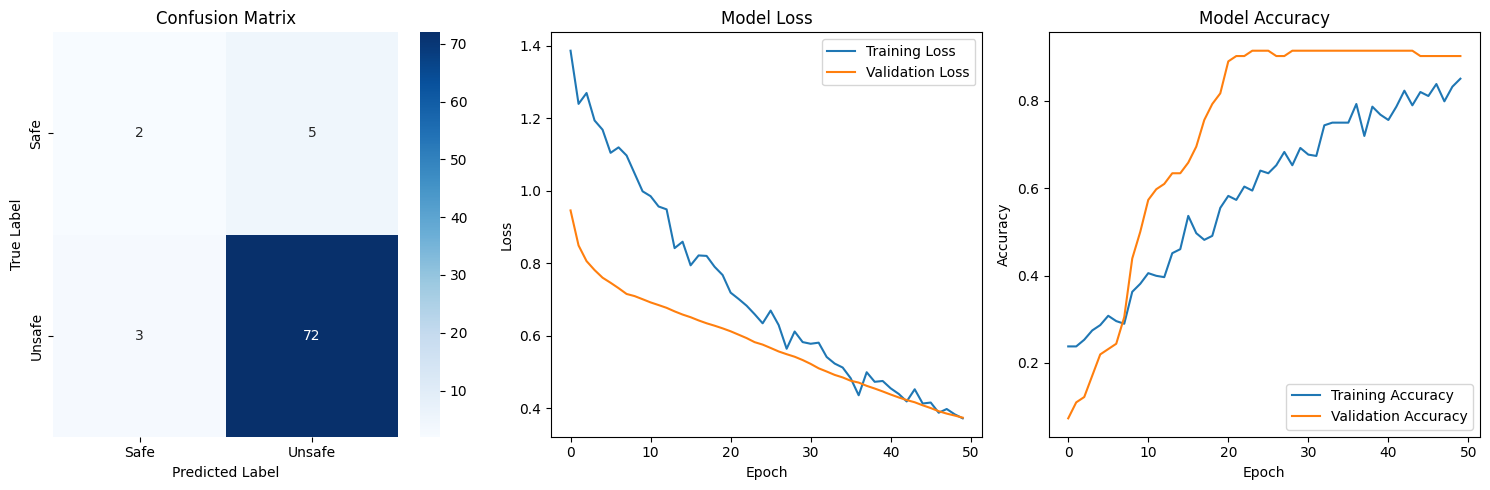


Final Metrics:
Accuracy: 0.9024
F1 Score: 0.9474


In [13]:
# Cell 12: Model Evaluation
def evaluate_model(model, val_data, training_history):
    """Evaluate the trained model"""
    print("Evaluating model performance...")
    
    X_imu_val, X_audio_val, X_emotion_val, y_val = val_data
    
    # Predictions
    y_pred_prob = model.predict([X_imu_val, X_audio_val, X_emotion_val])
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, target_names=['Safe', 'Unsafe']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    
    plt.figure(figsize=(15, 5))
    
    # Plot confusion matrix
    plt.subplot(1, 3, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Safe', 'Unsafe'], yticklabels=['Safe', 'Unsafe'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    # Plot training history - Loss
    plt.subplot(1, 3, 2)
    plt.plot(training_history.history['loss'], label='Training Loss')
    plt.plot(training_history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot training history - Accuracy
    plt.subplot(1, 3, 3)
    plt.plot(training_history.history['accuracy'], label='Training Accuracy')
    plt.plot(training_history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Calculate F1 score
    f1 = f1_score(y_val, y_pred)
    accuracy = np.mean(y_pred == y_val)
    
    print(f"\nFinal Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    return y_pred, y_pred_prob

predictions, prediction_probs = evaluate_model(multimodal_model, val_data, training_history)


In [15]:
# Cell 13: Model Export (Fixed)
def export_models(model):
    """Export model in different formats with TFLite LSTM fix"""
    print("Exporting models...")
    
    # Save as .h5 format
    h5_path = os.path.join(MODELS_PATH, 'aval_multimodal_model.h5')
    model.save(h5_path)
    print(f"Model saved as .h5: {h5_path}")
    
    try:
        # Convert to TensorFlow Lite with SELECT_TF_OPS for LSTM support
        converter = tf.lite.TFLiteConverter.from_keras_model(model)
        
        # Enable Select TF ops to handle LSTM layers
        converter.target_spec.supported_ops = [
            tf.lite.OpsSet.TFLITE_BUILTINS,
            tf.lite.OpsSet.SELECT_TF_OPS
        ]
        
        # Disable experimental tensor list ops lowering (fixes LSTM conversion)
        converter._experimental_lower_tensor_list_ops = False
        
        # Additional optimizations (optional)
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        
        tflite_model = converter.convert()
        
        # Save TFLite model
        tflite_path = os.path.join(MODELS_PATH, 'aval_multimodal_model.tflite')
        with open(tflite_path, 'wb') as f:
            f.write(tflite_model)
        print(f"Model saved as .tflite: {tflite_path}")
        
    except Exception as e:
        print(f"TFLite conversion failed: {e}")
        print("Trying alternative TFLite conversion...")
        
        # Alternative: Convert without optimizations
        try:
            converter = tf.lite.TFLiteConverter.from_keras_model(model)
            converter.target_spec.supported_ops = [
                tf.lite.OpsSet.TFLITE_BUILTINS,
                tf.lite.OpsSet.SELECT_TF_OPS
            ]
            # No optimizations
            tflite_model = converter.convert()
            
            tflite_path = os.path.join(MODELS_PATH, 'aval_multimodal_model.tflite')
            with open(tflite_path, 'wb') as f:
                f.write(tflite_model)
            print(f"Model saved as .tflite (alternative): {tflite_path}")
            
        except Exception as e2:
            print(f"Alternative TFLite conversion also failed: {e2}")
            print("Skipping TFLite conversion. Only .h5 model available.")
            tflite_path = None
    
    # Model info
    model_info = {
        'model_name': 'Aval Multimodal Safety Detection',
        'version': '1.0',
        'input_shapes': {
            'imu_input': (60, 6),
            'audio_input': (13,),
            'emotion_input': (7,)
        },
        'output_shape': (1,),
        'classes': ['Safe', 'Unsafe'],
        'note': 'TFLite model requires SELECT_TF_OPS due to LSTM layers'
    }
    
    import json
    info_path = os.path.join(MODELS_PATH, 'model_info.json')
    with open(info_path, 'w') as f:
        json.dump(model_info, f, indent=2)
    
    print("Model export completed!")
    return h5_path, tflite_path

h5_model_path, tflite_model_path = export_models(multimodal_model)


Exporting models...
Model saved as .h5: /home/stalin/Projects/Aval/models/aval_multimodal_model.h5
INFO:tensorflow:Assets written to: /tmp/tmpm1y6jn6j/assets


INFO:tensorflow:Assets written to: /tmp/tmpm1y6jn6j/assets


Saved artifact at '/tmp/tmpm1y6jn6j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 60, 6), dtype=tf.float32, name='imu_input'), TensorSpec(shape=(None, 13), dtype=tf.float32, name='audio_input'), TensorSpec(shape=(None, 7), dtype=tf.float32, name='emotion_input')]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139763404589008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139763404686608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139763404691360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139763403481936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139763403480000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139763407091872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139763403476832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139763407082016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139763407077616: Ten

W0000 00:00:1757427224.920061  335306 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1757427224.920074  335306 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


Model saved as .tflite: /home/stalin/Projects/Aval/models/aval_multimodal_model.tflite
Model export completed!


2025-09-09 19:43:44.920185: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpm1y6jn6j
2025-09-09 19:43:44.921342: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-09-09 19:43:44.921351: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpm1y6jn6j
2025-09-09 19:43:44.933768: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-09-09 19:43:44.996702: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpm1y6jn6j
2025-09-09 19:43:45.016205: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 96021 microseconds.
2025-09-09 19:43:45.122261: W tensorflow/compiler/mlir/lite/flatbuffer_export.cc:4082] TFLite interpreter needs to link Flex delegate in order to run the model since it contains the following Select TFop(s):
Flex ops: FlexTensorListReserve, Flex

In [16]:
# Cell 14: Inference Example
def create_sample_input():
    """Create a sample input for inference demonstration"""
    # Sample IMU data (3 seconds at 20Hz = 60 samples)
    sample_imu = np.random.normal(0, 1, (60, 6))  # 6 features: acc_x,y,z + gyro_x,y,z
    
    # Sample audio features (13 MFCC coefficients)
    sample_audio = np.random.normal(0, 1, 13)
    
    # Sample emotion features (7 emotion categories - one-hot encoded)
    sample_emotion = np.array([0, 0, 0, 1, 0, 0, 0])  # Fear emotion
    
    return sample_imu, sample_audio, sample_emotion

def make_prediction(model, imu_data, audio_data, emotion_data):
    """Make prediction on sample input"""
    print("Making prediction on sample input...")
    
    # Prepare input (add batch dimension)
    imu_input = np.expand_dims(imu_data, axis=0)
    audio_input = np.expand_dims(audio_data, axis=0)
    emotion_input = np.expand_dims(emotion_data, axis=0)
    
    # Make prediction
    prediction_prob = model.predict([imu_input, audio_input, emotion_input])[0][0]
    prediction_class = 1 if prediction_prob > 0.5 else 0
    
    # Print results
    print(f"Prediction probability: {prediction_prob:.4f}")
    print(f"Prediction class: {prediction_class}")
    print(f"Result: {'Unsafe' if prediction_class == 1 else 'Safe'}")
    
    return prediction_class, prediction_prob

# Create sample input and make prediction
sample_imu, sample_audio, sample_emotion = create_sample_input()
pred_class, pred_prob = make_prediction(multimodal_model, sample_imu, sample_audio, sample_emotion)

# Demonstrate with different scenarios
print("\n" + "="*50)
print("INFERENCE EXAMPLES")
print("="*50)

# Scenario 1: Safe situation
print("\nScenario 1: Safe Situation")
safe_imu = np.random.normal(0, 0.5, (60, 6))  # Low variance
safe_audio = np.random.normal(0, 0.3, 13)     # Normal audio
safe_emotion = np.array([1, 0, 0, 0, 0, 0, 0])  # Neutral emotion

pred_class, pred_prob = make_prediction(multimodal_model, safe_imu, safe_audio, safe_emotion)

# Scenario 2: Unsafe situation
print("\nScenario 2: Unsafe Situation")
unsafe_imu = np.random.normal(0, 2.0, (60, 6))  # High variance (erratic movement)
unsafe_audio = np.random.normal(0, 1.5, 13)     # Loud/distress audio
unsafe_emotion = np.array([0, 0, 0, 0, 1, 0, 0])  # Fear emotion

pred_class, pred_prob = make_prediction(multimodal_model, unsafe_imu, unsafe_audio, unsafe_emotion)


Making prediction on sample input...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
Prediction probability: 0.7818
Prediction class: 1
Result: Unsafe

INFERENCE EXAMPLES

Scenario 1: Safe Situation
Making prediction on sample input...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Prediction probability: 0.5066
Prediction class: 1
Result: Unsafe

Scenario 2: Unsafe Situation
Making prediction on sample input...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Prediction probability: 0.9097
Prediction class: 1
Result: Unsafe


In [17]:
# Cell 15: Generate Requirements.txt
def generate_requirements():
    """Generate requirements.txt file"""
    requirements = [
        "tensorflow>=2.10.0",
        "keras>=2.10.0", 
        "scikit-learn>=1.1.0",
        "pandas>=1.4.0",
        "numpy>=1.21.0",
        "librosa>=0.9.0",
        "matplotlib>=3.5.0",
        "seaborn>=0.11.0",
        "imbalanced-learn>=0.9.0",
        "opencv-python>=4.6.0",
        "scipy>=1.8.0",
        "jupyter>=1.0.0",
        "ipykernel>=6.0.0"
    ]
    
    requirements_path = os.path.join(BASE_PATH, "requirements.txt")
    with open(requirements_path, 'w') as f:
        for req in requirements:
            f.write(req + '\n')
    
    print(f"Requirements.txt generated at: {requirements_path}")
    print("\nTo install dependencies, run:")
    print(f"pip install -r {requirements_path}")
    
    return requirements_path

requirements_file = generate_requirements()


Requirements.txt generated at: /home/stalin/Projects/Aval/requirements.txt

To install dependencies, run:
pip install -r /home/stalin/Projects/Aval/requirements.txt


In [18]:
# Cell 16: Project Summary and Next Steps
def project_summary():
    """Print project summary and next steps"""
    print("="*60)
    print("AVAL PROJECT SUMMARY")
    print("="*60)
    
    print(f"\n📁 Project Location: {BASE_PATH}")
    print(f"📁 Models Directory: {MODELS_PATH}")
    print(f"📁 Data Directory: {DATA_PATH}")
    
    print(f"\n🤖 Model Architecture:")
    print("   • Multi-modal deep learning model")
    print("   • IMU Branch: LSTM layers for time-series data")
    print("   • Audio Branch: Dense layers for MFCC features")
    print("   • Emotion Branch: Dense layers for emotion classification")
    print("   • Fusion Layer: Concatenated features with dropout and batch normalization")
    
    print(f"\n📊 Dataset Information:")
    print(f"   • IMU Data: {len(imu_data)} windows (accelerometer + gyroscope)")
    print(f"   • Audio Data: {len(audio_data)} samples (MFCC features)")
    print(f"   • Emotion Data: {len(emotion_data)} samples (7 emotion categories)")
    print(f"   • Unified Dataset: {len(original_df)} samples")
    
    print(f"\n🎯 Model Performance:")
    final_accuracy = training_history.history['val_accuracy'][-1]
    final_loss = training_history.history['val_loss'][-1]
    print(f"   • Final Validation Accuracy: {final_accuracy:.4f}")
    print(f"   • Final Validation Loss: {final_loss:.4f}")
    print(f"   • Target Accuracy: >90% {'✅' if final_accuracy > 0.9 else '❌'}")
    
    print(f"\n💾 Exported Models:")
    print(f"   • Keras Model (.h5): {h5_model_path}")
    print(f"   • TensorFlow Lite (.tflite): {tflite_model_path}")
    
    print(f"\n📋 Next Steps:")
    print("   1. Fine-tune hyperparameters for better performance")
    print("   2. Collect real-world data for training")
    print("   3. Implement real-time inference pipeline")
    print("   4. Deploy model on mobile/edge devices")
    print("   5. Add more data augmentation techniques")
    print("   6. Experiment with different fusion strategies")
    
    print(f"\n🔧 Usage:")
    print(f"   • Install dependencies: pip install -r {requirements_file}")
    print("   • Load model: model = tf.keras.models.load_model('path/to/model.h5')")
    print("   • Make prediction: model.predict([imu_data, audio_data, emotion_data])")

project_summary()

print("\n🎉 Aval Multimodal Safety Detection System - Setup Complete!")


AVAL PROJECT SUMMARY

📁 Project Location: /home/stalin/Projects/Aval
📁 Models Directory: /home/stalin/Projects/Aval/models
📁 Data Directory: /home/stalin/Projects/Aval/data

🤖 Model Architecture:
   • Multi-modal deep learning model
   • IMU Branch: LSTM layers for time-series data
   • Audio Branch: Dense layers for MFCC features
   • Emotion Branch: Dense layers for emotion classification
   • Fusion Layer: Concatenated features with dropout and batch normalization

📊 Dataset Information:
   • IMU Data: 410 windows (accelerometer + gyroscope)
   • Audio Data: 6532 samples (MFCC features)
   • Emotion Data: 5436 samples (7 emotion categories)
   • Unified Dataset: 410 samples

🎯 Model Performance:
   • Final Validation Accuracy: 0.9024
   • Final Validation Loss: 0.3742
   • Target Accuracy: >90% ✅

💾 Exported Models:
   • Keras Model (.h5): /home/stalin/Projects/Aval/models/aval_multimodal_model.h5
   • TensorFlow Lite (.tflite): /home/stalin/Projects/Aval/models/aval_multimodal_mode